# 1. EDA

**Course:** TC5035.10 - Capstone project
**Tecnológico de Monterrey**

**Professor:** Raúl Valente Ramírez Velarde

---
**Team:** 57
> César Miguel Barrientos Robles - A01796615
>
> Alan Julian Rodríguez García - A01796833

## Context
According to Mexico's 2020 Population and Housing Census (INEGI), Mexico registered 6.1 million people with some form of disability,
21.9% of whom — approximately 1.35 million — are deaf or hard of hearing. For many of them, Mexican Sign Language (LSM) is their primary means of communication. Yet the vast majority of the hearing population has no exposure to it, creating a persistent communication barrier hat technology has largely failed to address.

LSM has its own vocabulary and a complex grammar that is very different from Spanish grammar — it is a complete, natural language of the Mexican deaf community, capable of expressing as wide a range of thoughts and emotions as any other language.  It is not simply Spanish translated into gestures. Despite being part of Mexico's national linguistic heritage, there are no official statistics on the precise number of LSM speakers or users.

LSM was officially recognized in the General Law for the Inclusion of Persons with Disabilities in 2005.  Since then, some progress has been made — certain news programs and government broadcasts include LSM interpretation — but digital tools built specifically for LSM remain scarce. Most existing sign language recognition systems are built for American Sign Language (ASL) and do not transfer well to LSM.

**manos-hablando** is a first step toward closing that gap. The full vision is a real-time pipeline that captures hand signs, recognizes them using a Transformer-based classifier trained specifically on LSM, and passes the recognized signs to a Large Language Model (LLM) that reconstructs natural Spanish from them — bridging the communication gap in real time.

This notebook documents the first look at the data — before any model sees it.

## EDA and preprocesing

### Descriptive Statistics

In [2]:
import json
from pathlib import Path

import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os

from manos_hablando.config import PROCESSED_DATA_DIR



2026-05-20 21:25:49.798 | INFO     | manos_hablando.config:<module>:11 - PROJ_ROOT path is: /Users/cbarrien/Documents/Projects/Personal/LSM/manos-hablando


In [3]:
LANDMARK_NAMES = [
    "WRIST",
    "THUMB_CMC", "THUMB_MCP", "THUMB_IP", "THUMB_TIP",
    "INDEX_MCP", "INDEX_PIP", "INDEX_DIP", "INDEX_TIP",
    "MIDDLE_MCP", "MIDDLE_PIP", "MIDDLE_DIP", "MIDDLE_TIP",
    "RING_MCP", "RING_PIP", "RING_DIP", "RING_TIP",
    "PINKY_MCP", "PINKY_PIP", "PINKY_DIP", "PINKY_TIP",
]

# Build column names: WRIST_x, WRIST_y, WRIST_z, THUMB_CMC_x, ...
columns = []
for name in LANDMARK_NAMES:
    for coord in ["x", "y", "z"]:
        columns.append(f"{name}_{coord}")

# Load and flatten
with open(PROCESSED_DATA_DIR / "keypoints.json") as f:
    data = json.load(f)

rows = []
for entry in data:
    row = {
        "letter": entry["letter"],
        "file": entry["file"],
        "handedness": entry["handedness"],
        "handedness_confidence": entry["handedness_confidence"],
    }

    # image keypoints
    flat = [coord for point in entry["keypoints"] for coord in point]
    row.update(dict(zip(columns, flat)))

    # world keypoints
    world_columns = [f"{name}_w{coord}" for name in LANDMARK_NAMES for coord in ["x", "y", "z"]]
    flat_world = [coord for point in entry["world_keypoints"] for coord in point]
    row.update(dict(zip(world_columns, flat_world)))

    rows.append(row)

df = pd.DataFrame(rows)
display(df.head())

,letter,file,handedness,handedness_confidence,WRIST_x,WRIST_y,WRIST_z,THUMB_CMC_x,THUMB_CMC_y,THUMB_CMC_z,...,PINKY_MCP_wz,PINKY_PIP_wx,PINKY_PIP_wy,PINKY_PIP_wz,PINKY_DIP_wx,PINKY_DIP_wy,PINKY_DIP_wz,PINKY_TIP_wx,PINKY_TIP_wy,PINKY_TIP_wz
0,A,A_63.jpg,Right,0.618247,0.215690,0.391573,1.093951e-06,0.353929,0.506949,-0.061486,...,0.006652,-0.013173,0.006764,-0.000570,-0.009514,0.017215,-0.004708,-0.002251,0.029172,-0.014473
1,A,A_6.jpg,Right,0.997630,0.799894,0.614623,-5.651171e-07,0.724600,0.438284,-0.026929,...,-0.010846,-0.011160,0.036658,-0.028339,-0.001282,0.027936,-0.048126,0.015557,0.026138,-0.038945
2,A,A_62.jpg,Right,0.893355,0.776529,0.625856,1.103114e-06,0.635659,0.491809,-0.066883,...,0.004921,0.031558,-0.005056,-0.000782,0.033954,-0.020744,-0.005247,0.032533,-0.031525,-0.007702
3,A,A_74.jpg,Right,0.995105,0.462465,0.869138,-4.816762e-07,0.613996,0.779986,-0.072542,...,-0.009904,-0.041577,-0.005833,-0.022848,-0.031534,-0.001850,-0.042985,-0.023223,0.013656,-0.039009
4,A,A_60.jpg,Right,0.998699,0.234172,0.784119,-3.596604e-07,0.423803,0.753789,-0.094595,...,-0.001048,-0.039739,-0.013366,-0.020144,-0.033777,-0.002799,-0.038218,-0.033392,0.008045,-0.021645


In [4]:
print("-" * 50)
print("Basic information about the dataset:")
print("-" * 50)
display(df.info())


--------------------------------------------------
Basic information about the dataset:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2057 entries, 0 to 2056
Columns: 130 entries, letter to PINKY_TIP_wz
dtypes: float64(127), object(3)
memory usage: 2.0+ MB


None

In [5]:
# Categorical columns
cat_cols = df.select_dtypes(include="object").columns.tolist()

# Numerical columns
num_cols = df.select_dtypes(include="float64").columns.tolist()

print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numerical columns ({len(num_cols)}): {num_cols}")

Categorical columns (3): ['letter', 'file', 'handedness']
Numerical columns (127): ['handedness_confidence', 'WRIST_x', 'WRIST_y', 'WRIST_z', 'THUMB_CMC_x', 'THUMB_CMC_y', 'THUMB_CMC_z', 'THUMB_MCP_x', 'THUMB_MCP_y', 'THUMB_MCP_z', 'THUMB_IP_x', 'THUMB_IP_y', 'THUMB_IP_z', 'THUMB_TIP_x', 'THUMB_TIP_y', 'THUMB_TIP_z', 'INDEX_MCP_x', 'INDEX_MCP_y', 'INDEX_MCP_z', 'INDEX_PIP_x', 'INDEX_PIP_y', 'INDEX_PIP_z', 'INDEX_DIP_x', 'INDEX_DIP_y', 'INDEX_DIP_z', 'INDEX_TIP_x', 'INDEX_TIP_y', 'INDEX_TIP_z', 'MIDDLE_MCP_x', 'MIDDLE_MCP_y', 'MIDDLE_MCP_z', 'MIDDLE_PIP_x', 'MIDDLE_PIP_y', 'MIDDLE_PIP_z', 'MIDDLE_DIP_x', 'MIDDLE_DIP_y', 'MIDDLE_DIP_z', 'MIDDLE_TIP_x', 'MIDDLE_TIP_y', 'MIDDLE_TIP_z', 'RING_MCP_x', 'RING_MCP_y', 'RING_MCP_z', 'RING_PIP_x', 'RING_PIP_y', 'RING_PIP_z', 'RING_DIP_x', 'RING_DIP_y', 'RING_DIP_z', 'RING_TIP_x', 'RING_TIP_y', 'RING_TIP_z', 'PINKY_MCP_x', 'PINKY_MCP_y', 'PINKY_MCP_z', 'PINKY_PIP_x', 'PINKY_PIP_y', 'PINKY_PIP_z', 'PINKY_DIP_x', 'PINKY_DIP_y', 'PINKY_DIP_z', 'PINKY

In [6]:
# Show the statistics of the numerical columns
df[ num_cols].describe()

,handedness_confidence,WRIST_x,WRIST_y,WRIST_z,THUMB_CMC_x,THUMB_CMC_y,THUMB_CMC_z,THUMB_MCP_x,THUMB_MCP_y,THUMB_MCP_z,...,PINKY_MCP_wz,PINKY_PIP_wx,PINKY_PIP_wy,PINKY_PIP_wz,PINKY_DIP_wx,PINKY_DIP_wy,PINKY_DIP_wz,PINKY_TIP_wx,PINKY_TIP_wy,PINKY_TIP_wz
count,2057.000000,2057.000000,2057.000000,2.057000e+03,2057.000000,2057.000000,2057.000000,2057.000000,2057.000000,2057.000000,...,2057.000000,2057.000000,2057.000000,2057.000000,2057.000000,2057.000000,2057.000000,2057.000000,2057.000000,2057.000000
mean,0.967223,0.480572,0.650360,-2.897747e-08,0.482694,0.619819,-0.024906,0.484810,0.573021,-0.043031,...,-0.005886,-0.003103,0.003337,-0.012398,-0.002293,0.003408,-0.013645,-0.001854,0.007231,-0.010628
std,0.065441,0.268858,0.194471,6.814772e-07,0.217950,0.169687,0.030560,0.187326,0.150977,0.047992,...,0.014065,0.024646,0.018301,0.017671,0.024799,0.025515,0.027731,0.026317,0.031822,0.034095
min,0.505272,-0.023785,-0.032846,-2.998706e-06,0.055463,0.082844,-0.195425,0.066835,0.084264,-0.362882,...,-0.046130,-0.049918,-0.053086,-0.046544,-0.069558,-0.064571,-0.054984,-0.083338,-0.084090,-0.063704
25%,0.973158,0.250131,0.513076,-3.481090e-07,0.300808,0.494025,-0.038649,0.335539,0.459378,-0.063333,...,-0.014359,-0.025490,-0.010665,-0.026424,-0.023304,-0.015349,-0.036053,-0.020350,-0.009998,-0.037468
50%,0.989309,0.405496,0.668723,2.897328e-08,0.437790,0.624399,-0.018264,0.454505,0.573278,-0.031826,...,-0.005407,-0.004210,0.004430,-0.016076,-0.004127,0.008383,-0.024068,-0.003992,0.015313,-0.022631
75%,0.996132,0.742720,0.802403,2.917660e-07,0.684179,0.748014,-0.006512,0.649056,0.683047,-0.013190,...,0.003667,0.018668,0.016740,0.001633,0.018662,0.024027,0.011229,0.016691,0.030989,0.022267
max,0.999922,1.058916,1.052532,3.677860e-06,0.966844,1.006467,0.144135,0.904617,0.956149,0.183174,...,0.043507,0.051261,0.046662,0.040537,0.059894,0.057003,0.054832,0.078715,0.066599,0.068122


In [7]:
# Show the statistics of the categorical columns
df[cat_cols].describe()

,letter,file,handedness
count,2057,2057,2057
unique,26,1209,2
top,RR,aug_0007.jpg,Right
freq,100,17,1152


In [8]:
# Counting right or left
handedness_summary = df["handedness"].value_counts().to_frame("count")
handedness_summary["percentage"] = df["handedness"].value_counts(normalize=True) * 100
print(handedness_summary)

            count  percentage
handedness                   
Right        1152   56.003889
Left          905   43.996111


#### Description of the dataset
The dataset consists of 2,057 samples across 26 letters of the LSM dactylological alphabet,
with each sample representing a single static hand sign captured from a real image. Each
sample contains 129 numerical features — 63 image coordinate columns (x, y, z per landmark
in normalized 0-1 image space), 63 world coordinate columns (x, y, z per landmark in
real-world meters), and handedness confidence — plus 3 categorical fields: the target
letter, the source filename, and handedness (left or right). The dataset is perfectly
complete with no missing values across any column.

**Class distribution:**
- Balanced at ~100 samples per letter across all 26 classes
- Achieved via volunteer images + augmentation
- RR is the most frequent class at exactly 100 samples

**Handedness:**
- 56% right hand (1,152 samples), 44% left hand (905 samples)
- Slight imbalance likely reflecting the dominance of right-handed contributors
- MediaPipe is highly confident about handedness — mean confidence of 96.7%
- Min confidence of 50.5% indicates a small number of ambiguous cases

**Image coordinates (x, y):**
- Mean x ≈ 0.48 — hands consistently centered horizontally
- Mean y ≈ 0.65 — hands tend to sit in the lower half of the frame
- Minor extrapolations beyond 0-1 observed (min: -0.03, max: 1.06) — hand near frame edge

**World coordinates:**
- Range ~-0.1 to +0.1 meters — origin at hand geometric center
- Much lower std (~0.03) vs image coordinates (~0.19) — more geometrically consistent
- Less affected by hand position in the frame making them potentially more useful for the model

**Z coordinate (depth):**
- Wrist z ≈ 0.0 always — serves as the depth reference point
- Fingertips show the most negative z values — closest to camera
- Clear depth gradient from wrist → knuckles → fingertips across all five fingers

### Analysis of outliers

In [9]:
# Detect outliers using IQR method
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR)))

print(f"Total outliers detected: {outliers.sum().sum()}")
print(f"\nOutliers per column (top 10):")
print(outliers.sum().sort_values(ascending=False).head(10))
print(f"\nRows with at least one outlier: {outliers.any(axis=1).sum()}")
print(f"Percentage of rows with outliers: {outliers.any(axis=1).sum() / len(df) * 100:.1f}%")

Total outliers detected: 4656

Outliers per column (top 10):
handedness_confidence    264
RING_TIP_wx              224
RING_TIP_wy              202
INDEX_MCP_z              179
MIDDLE_MCP_z             166
WRIST_z                  159
RING_MCP_z               149
PINKY_TIP_z              125
MIDDLE_PIP_z             124
MIDDLE_TIP_wx            123
dtype: int64

Rows with at least one outlier: 1086
Percentage of rows with outliers: 52.8%


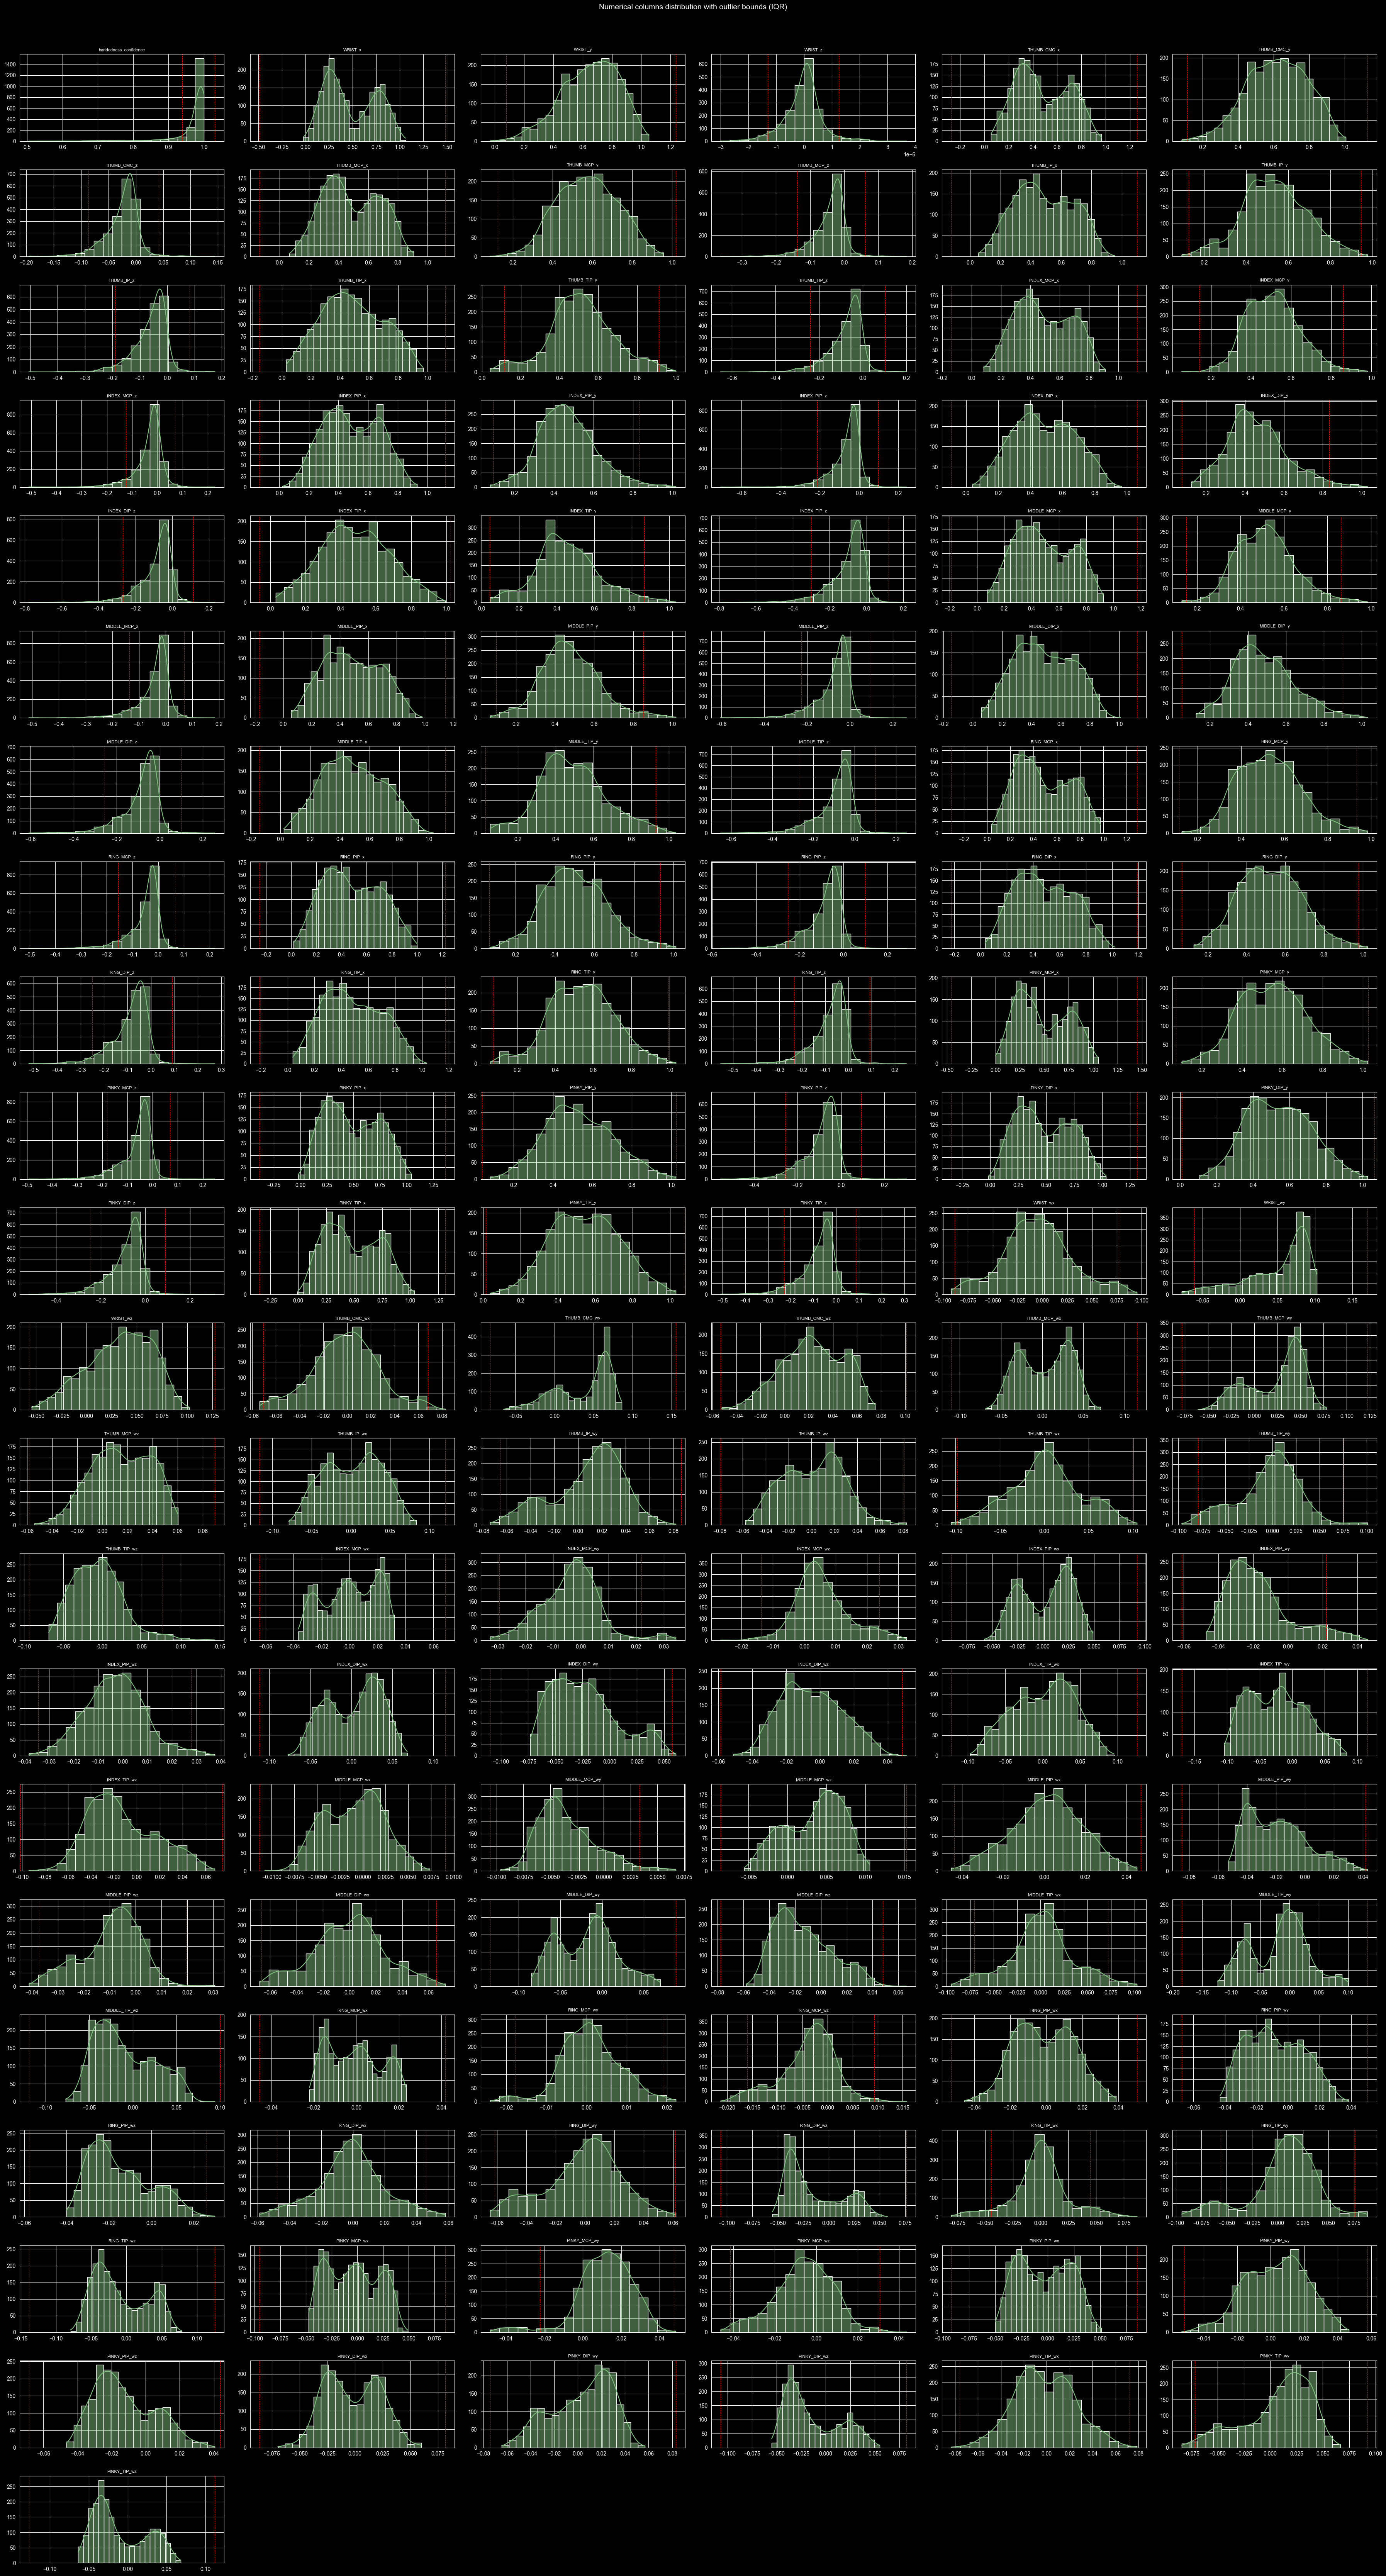

In [10]:
import math
import seaborn as sns

# Compute grid size
n = len(num_cols)
ncols = 6
nrows = math.ceil(n / ncols)

# Create subplots
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 3*nrows))
axes = axes.flatten()

# Plot each histogram
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), kde=True, bins=20, ax=ax, color='#7fbf7f')

    # highlight outlier bounds
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    ax.axvline(Q1 - 1.5 * IQR, color='red', linestyle='--', linewidth=0.8)
    ax.axvline(Q3 + 1.5 * IQR, color='red', linestyle='--', linewidth=0.8)

    ax.set_title(col, fontsize=8)
    ax.set_xlabel('')
    ax.set_ylabel('')

# Turn off any unused axes
for ax in axes[n:]:
    ax.axis('off')

plt.suptitle("Numerical columns distribution with outlier bounds (IQR)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### Categorical Variable Frequencies

In [11]:
# Categorical cardinalities
print("Categorical cardinalities:")
for col in cat_cols:
    uniq = df[col].nunique()
    print(f"  {col}: {uniq} unique values")

Categorical cardinalities:
  letter: 26 unique values
  file: 1209 unique values
  handedness: 2 unique values


In [12]:
# Compute skewness
skews = df[num_cols].skew().sort_values()
print("Top 10 most negative skews:\n", skews.head(10))
print("\nTop 10 most positive skews:\n", skews.tail(10))

Top 10 most negative skews:
 handedness_confidence   -3.804671
INDEX_MCP_z             -2.160707
MIDDLE_MCP_z            -2.085717
INDEX_PIP_z             -2.062632
INDEX_DIP_z             -1.950297
RING_MCP_z              -1.887026
INDEX_TIP_z             -1.882586
MIDDLE_PIP_z            -1.802765
PINKY_MCP_z             -1.635358
MIDDLE_DIP_z            -1.614884
dtype: float64

Top 10 most positive skews:
 INDEX_DIP_y      0.575436
MIDDLE_DIP_wz    0.601303
RING_PIP_wz      0.618869
MIDDLE_PIP_wy    0.620118
INDEX_DIP_wy     0.627358
PINKY_DIP_wz     0.663652
RING_DIP_wz      0.713411
THUMB_TIP_wz     0.773225
MIDDLE_MCP_wy    0.907675
INDEX_PIP_wy     1.072667
dtype: float64


In [13]:
# Features with |skew| > 1
heavy = skews[skews.abs() > 1]
print(f"\nFeatures with |skew| > 1 ({len(heavy)}):\n", heavy)


Features with |skew| > 1 (23):
 handedness_confidence   -3.804671
INDEX_MCP_z             -2.160707
MIDDLE_MCP_z            -2.085717
INDEX_PIP_z             -2.062632
INDEX_DIP_z             -1.950297
RING_MCP_z              -1.887026
INDEX_TIP_z             -1.882586
MIDDLE_PIP_z            -1.802765
PINKY_MCP_z             -1.635358
MIDDLE_DIP_z            -1.614884
MIDDLE_TIP_z            -1.605557
THUMB_TIP_z             -1.513762
RING_TIP_z              -1.496221
RING_PIP_z              -1.448806
THUMB_IP_z              -1.426717
RING_DIP_z              -1.350119
PINKY_PIP_z             -1.315005
THUMB_MCP_z             -1.295047
PINKY_TIP_z             -1.280535
PINKY_DIP_z             -1.227344
WRIST_wy                -1.108671
PINKY_MCP_wy            -1.072940
INDEX_PIP_wy             1.072667
dtype: float64


In [14]:
# Categorical Variable Frequencies
print("\n--- Categorical Variable Frequencies ---")
for col in cat_cols:
    print(f"\nValue Counts for {col}:")
    counts = df[col].value_counts(dropna=False)
    counts_df = pd.DataFrame({col: counts.index, 'Count': counts.values})
    try:
        counts_df = counts_df.sort_values(by=col)
    except TypeError:
        counts_df = counts_df.sort_values(by='Count', ascending=False)
    print(counts_df.to_markdown(index=False, numalign="left", stralign="left"))


--- Categorical Variable Frequencies ---

Value Counts for letter:
| letter   | Count   |
|:---------|:--------|
| A        | 75      |
| B        | 59      |
| C        | 47      |
| D        | 51      |
| E        | 90      |
| F        | 81      |
| G        | 90      |
| H        | 86      |
| I        | 85      |
| K        | 78      |
| L        | 83      |
| LL       | 89      |
| M        | 72      |
| N        | 64      |
| O        | 94      |
| P        | 81      |
| Q        | 55      |
| R        | 90      |
| RR       | 100     |
| S        | 76      |
| T        | 45      |
| U        | 90      |
| V        | 91      |
| W        | 95      |
| X        | 96      |
| Y        | 94      |

Value Counts for file:
| file         | Count   |
|:-------------|:--------|
| A_102.jpg    | 1       |
| A_107.jpg    | 1       |
| A_108.jpg    | 1       |
| A_109.jpg    | 1       |
| A_114.jpg    | 1       |
| A_119.jpg    | 1       |
| A_12.jpg     | 1       |
| A_122.jpg    | 1   

### Letter distribution

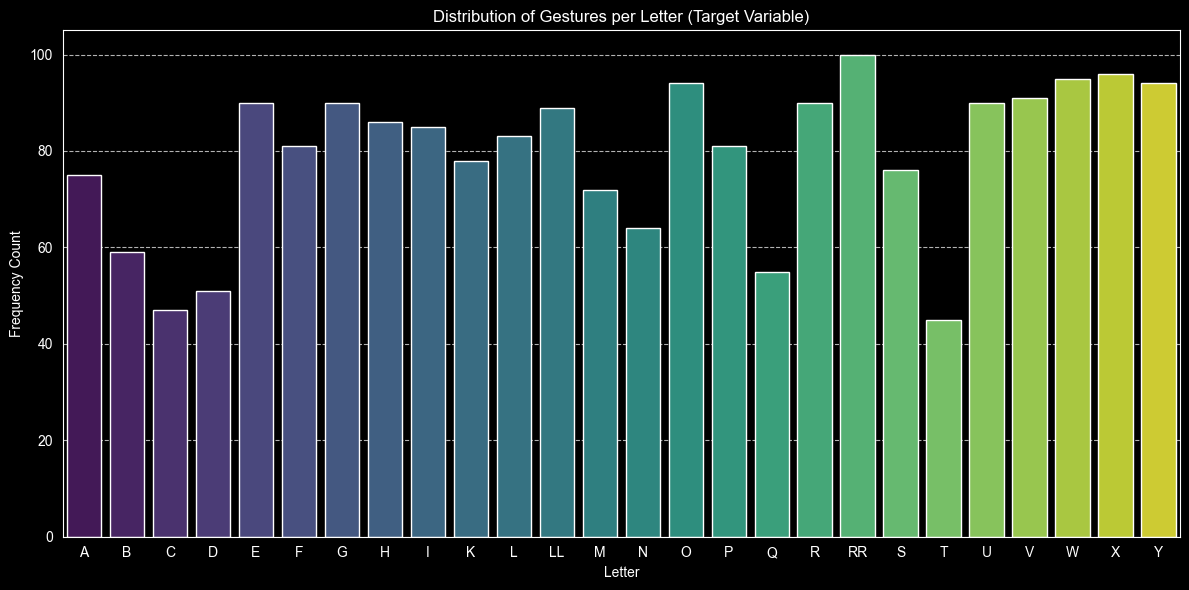

In [15]:
# Alphabetical order
letter_order = df['letter'].value_counts().sort_index().index

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='letter', hue='letter', order=letter_order, palette='viridis')
plt.title('Distribution of Gestures per Letter (Target Variable)')
plt.xlabel('Letter')
plt.ylabel('Frequency Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

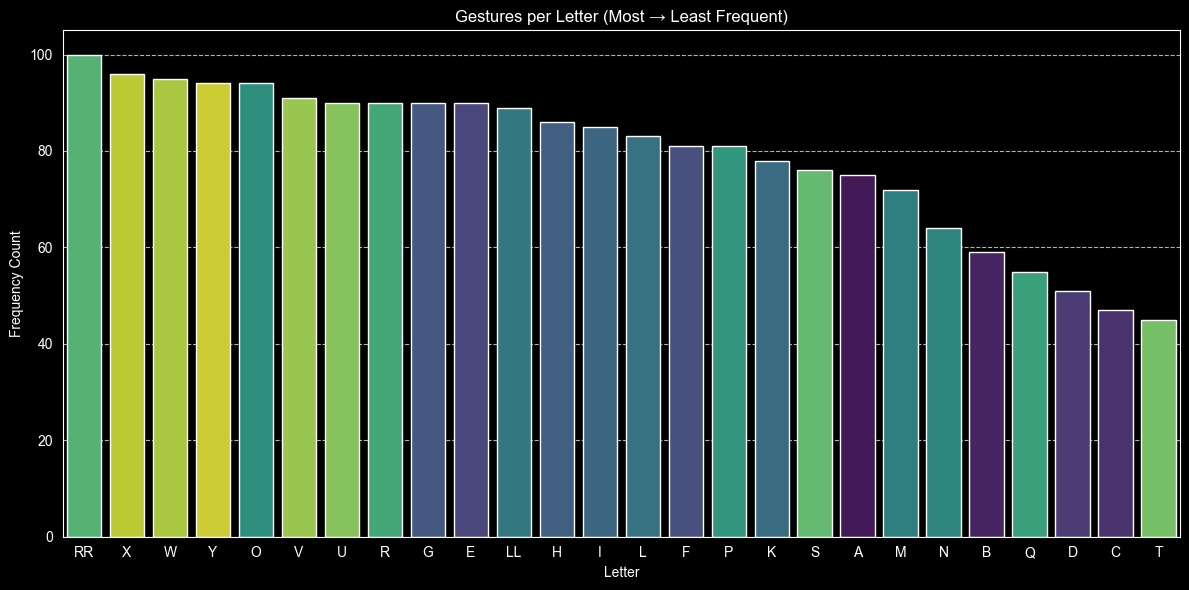

In [16]:
# Most to least frequent
letter_order_desc = df['letter'].value_counts().index

plt.figure(figsize=(12, 6))
sns.countplot(
    data=df,
    x='letter',
    hue='letter',
    order=letter_order_desc,
    palette='viridis',
)
plt.title('Gestures per Letter (Most → Least Frequent)')
plt.xlabel('Letter')
plt.ylabel('Frequency Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Bivariate analysis

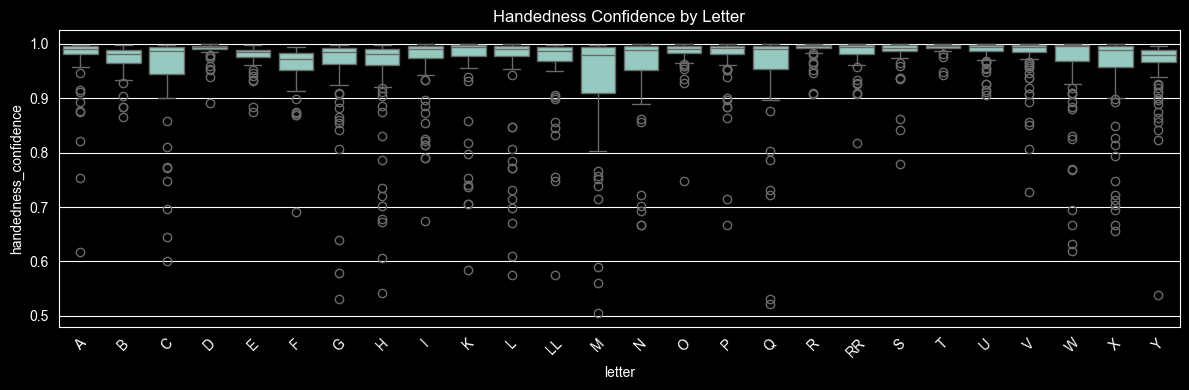

In [17]:
# Numeric vs Categorical - Confidence by Letter
plt.figure(figsize=(12, 4))
sns.boxplot(x='letter', y='handedness_confidence', data=df)
plt.xticks(rotation=45)
plt.title("Handedness Confidence by Letter")
plt.tight_layout()
plt.show()

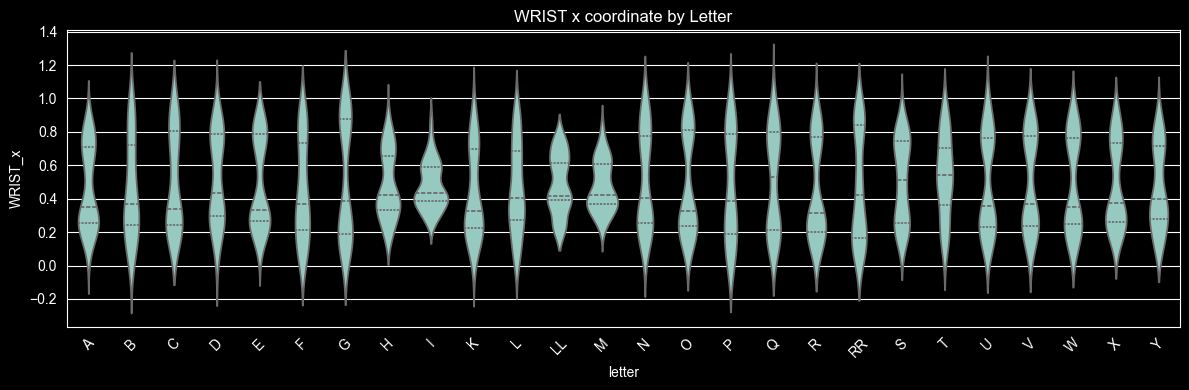

In [18]:
# Violin plot - WRIST_x by Letter
plt.figure(figsize=(12, 4))
sns.violinplot(x='letter', y='WRIST_x', data=df, inner='quartile')
plt.xticks(rotation=45)
plt.title("WRIST x coordinate by Letter")
plt.tight_layout()
plt.show()

In [19]:
# Categorical vs Categorical - Handedness by Letter
ct = pd.crosstab(df['letter'], df['handedness'])
display(ct)

handedness,Left,Right
letter,,
A,35,40
B,23,36
C,23,24
D,26,25
E,38,52
F,34,47
G,44,46
H,33,53
I,33,52


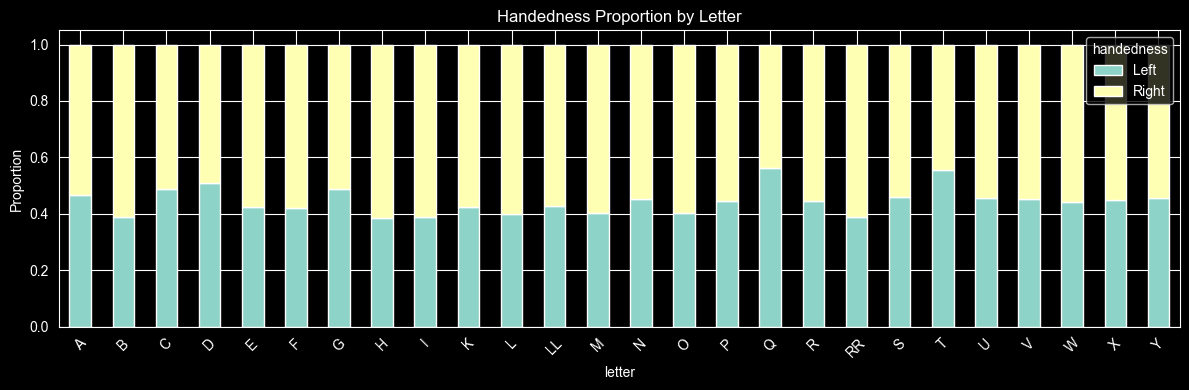

In [20]:
# Stacked bar - Handedness proportion by Letter
ct_norm = ct.div(ct.sum(axis=1), axis=0)
ct_norm.plot(kind='bar', stacked=True, figsize=(12, 4))
plt.title("Handedness Proportion by Letter")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

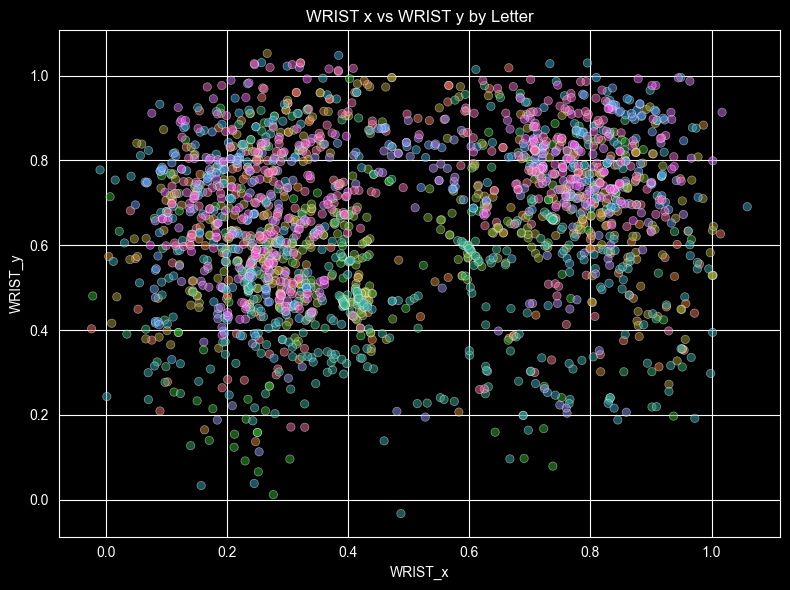

In [21]:
# Numeric vs Numeric - WRIST_x vs WRIST_y by Letter
plt.figure(figsize=(8, 6))
sns.scatterplot(x='WRIST_x', y='WRIST_y', hue='letter', data=df, legend=False, alpha=0.5)
plt.title("WRIST x vs WRIST y by Letter")
plt.tight_layout()
plt.show()

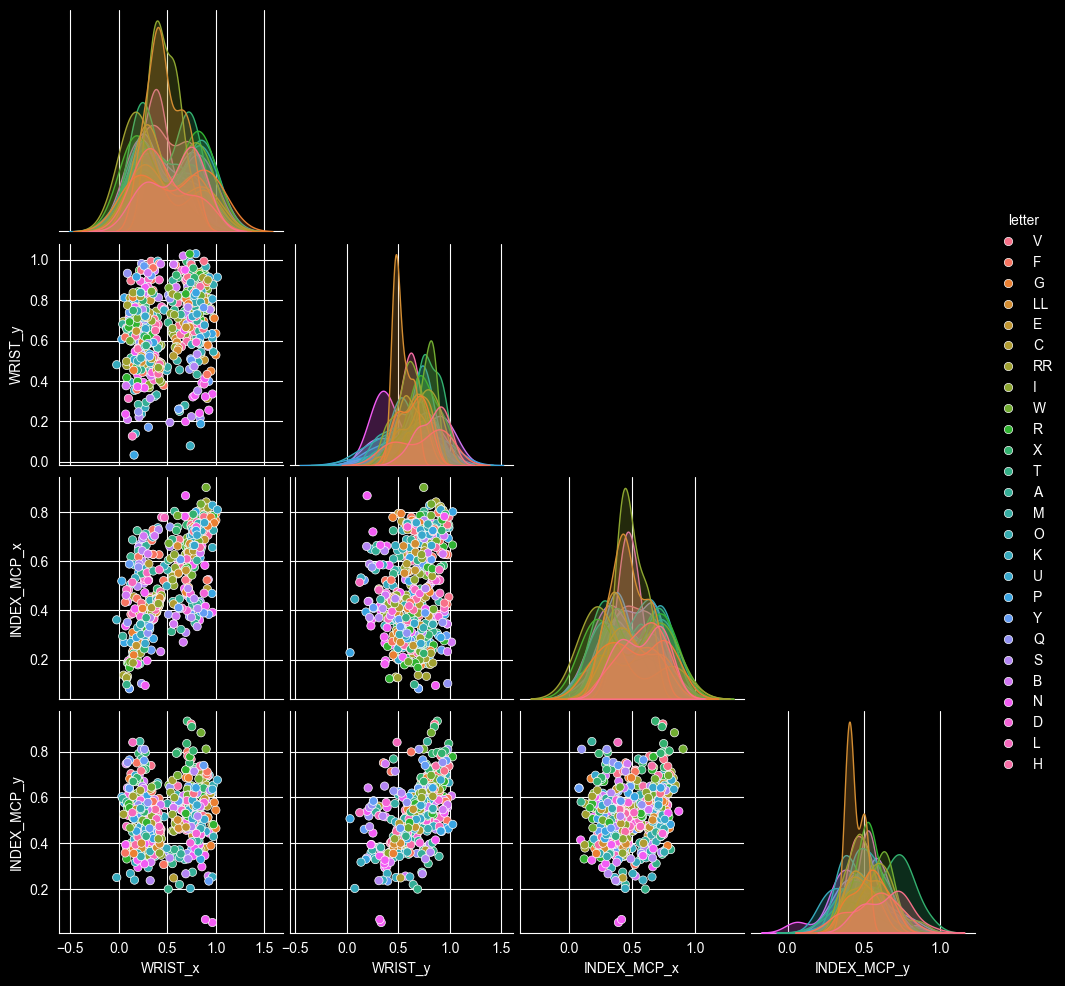

In [22]:
# Pairplot sample
sample = df.sample(500)
sns.pairplot(sample, vars=['WRIST_x', 'WRIST_y', 'INDEX_MCP_x', 'INDEX_MCP_y'], hue='letter', corner=True)
plt.show()

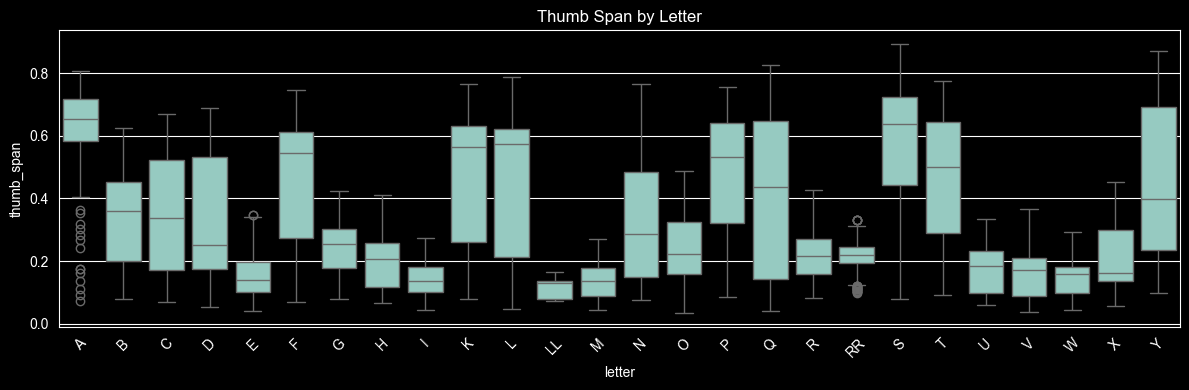

In [23]:
# Derived feature - thumb span (distance from wrist to thumb tip)
df['thumb_span'] = ((df['THUMB_TIP_x'] - df['WRIST_x'])**2 +
                    (df['THUMB_TIP_y'] - df['WRIST_y'])**2)**0.5

plt.figure(figsize=(12, 4))
sns.boxplot(x='letter', y='thumb_span', data=df)
plt.xticks(rotation=45)
plt.title("Thumb Span by Letter")
plt.tight_layout()
plt.show()

### Correlation Analysis


--- Bivariate Analysis: Correlation Matrix ---


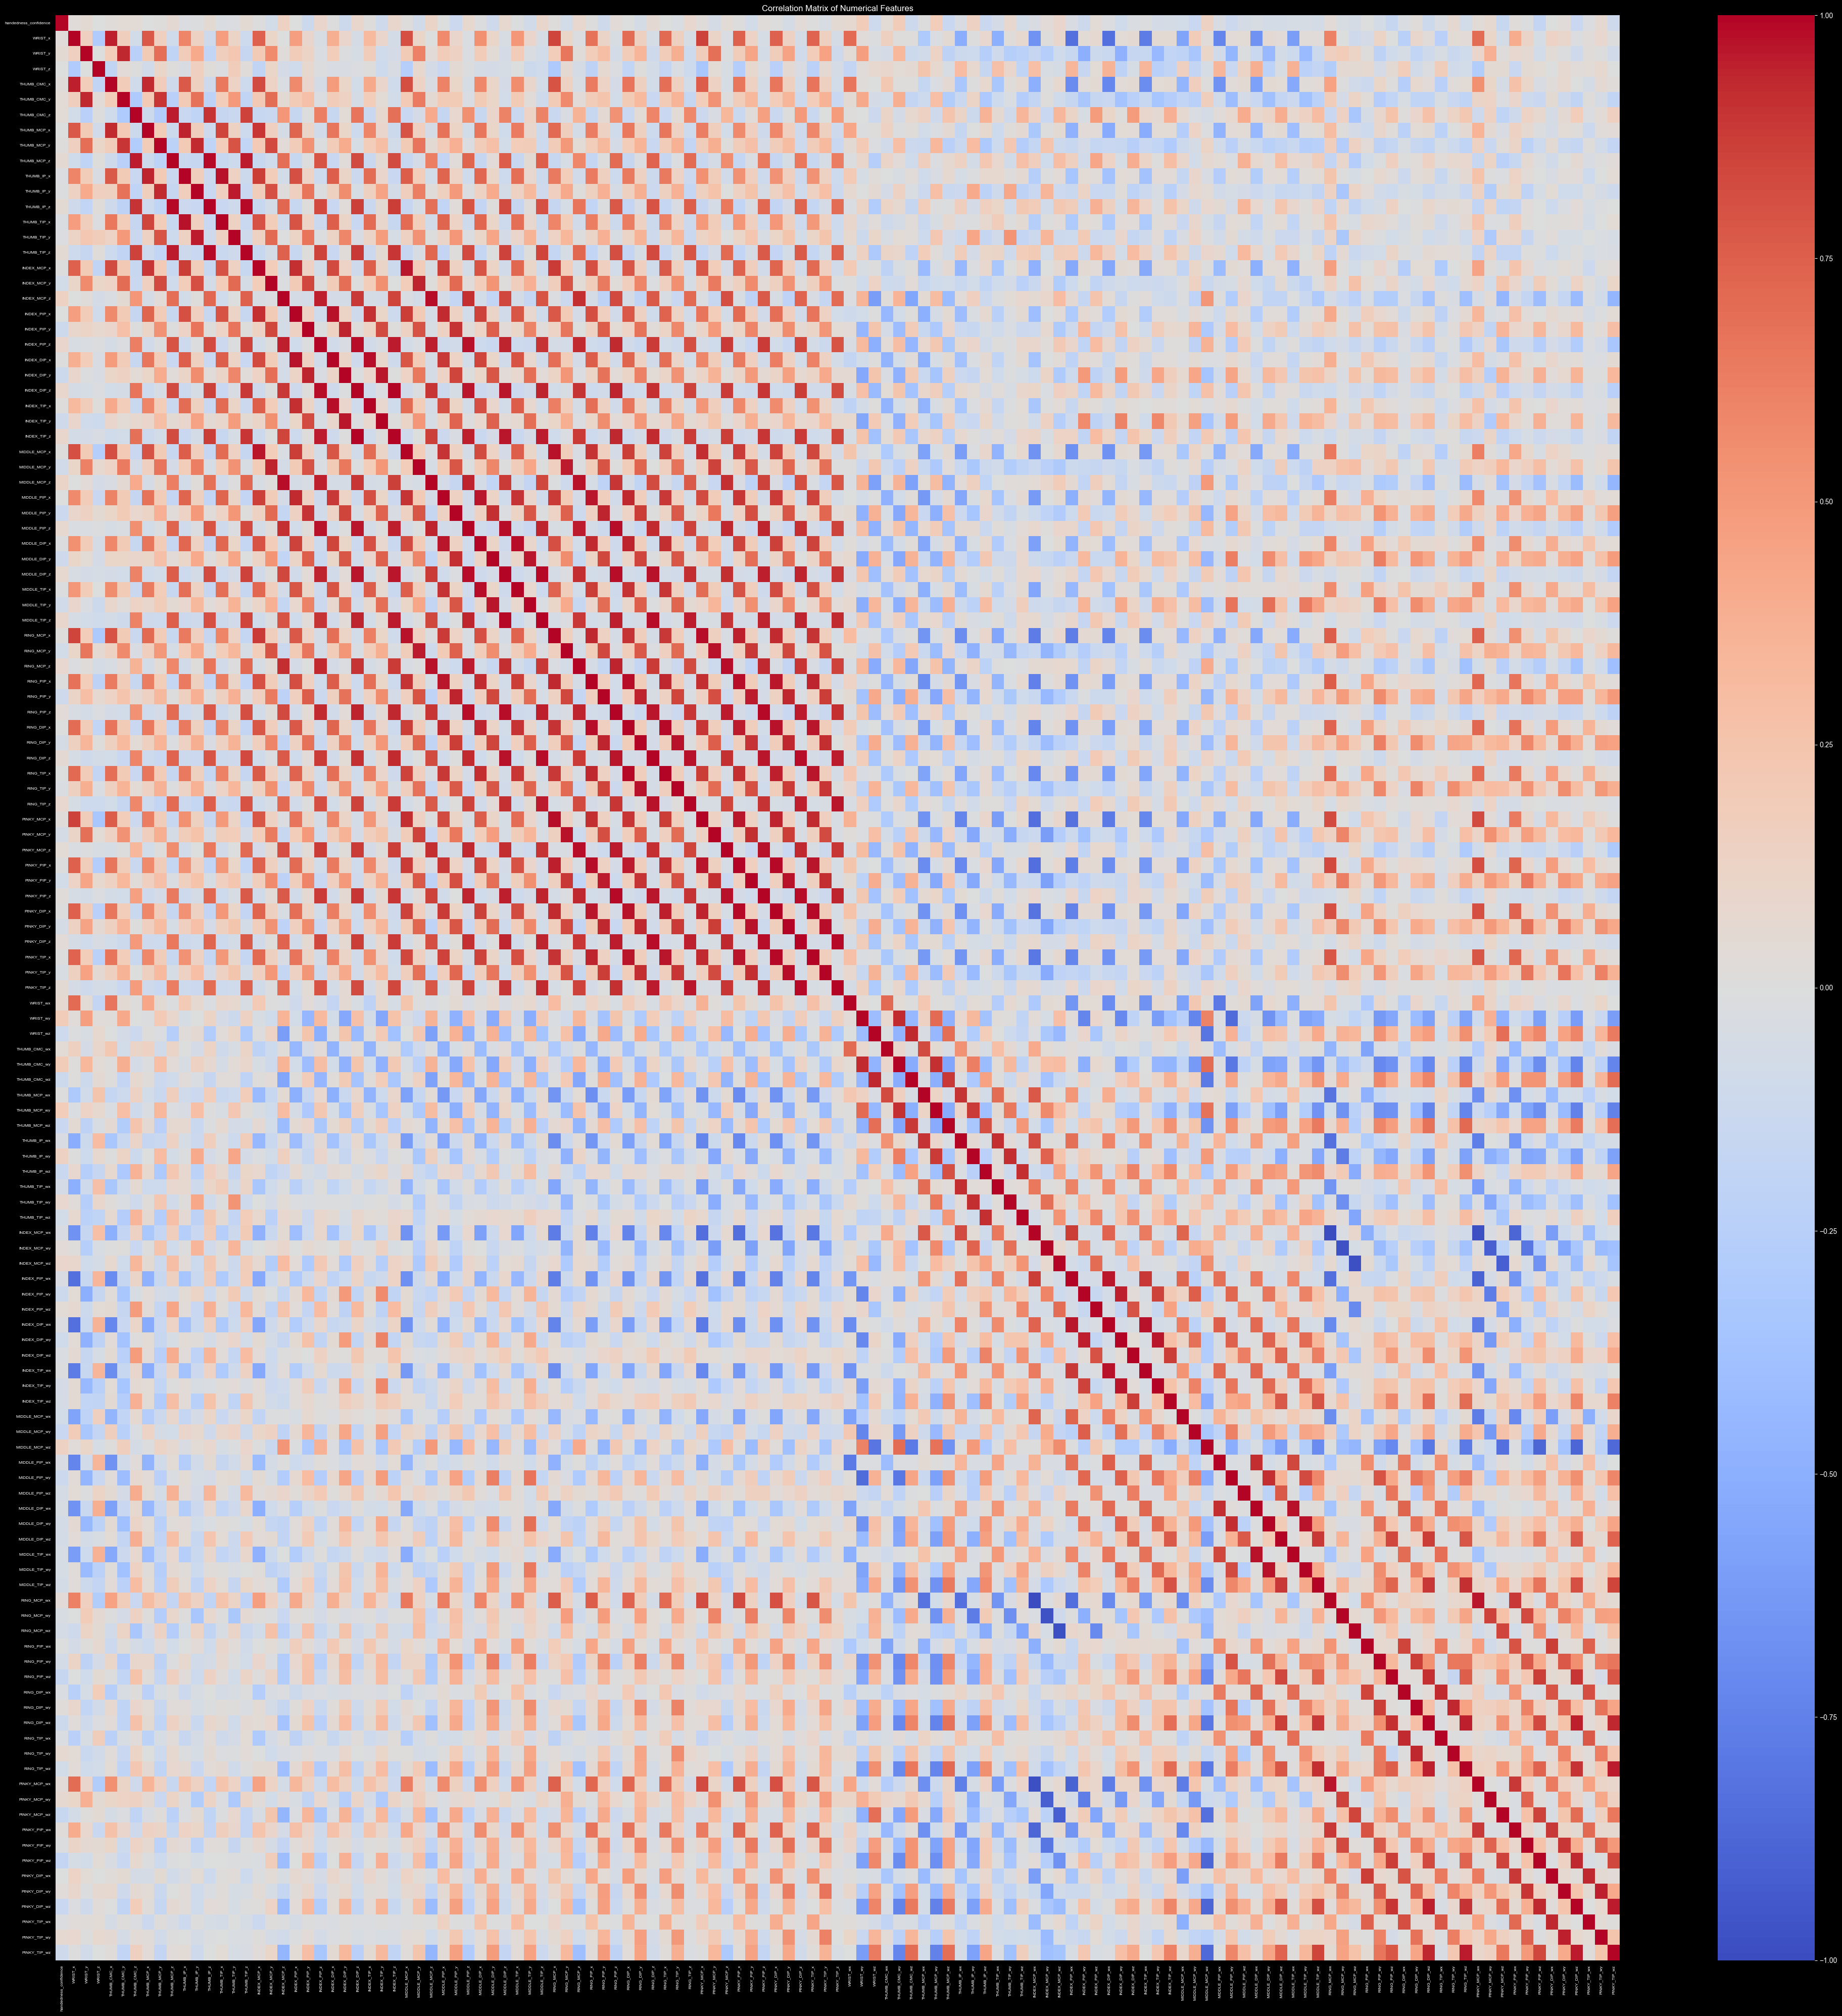

In [24]:
# Correlation Matrix
print("\n--- Bivariate Analysis: Correlation Matrix ---")

correlation_matrix = df[num_cols].corr()

plt.figure(figsize=(40, 40))
sns.heatmap(
    correlation_matrix,
    annot=False,      # too many columns for annotations
    cmap='coolwarm',
    linewidths=0,
    vmin=-1,
    vmax=1,
)
plt.title('Correlation Matrix of Numerical Features')
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.show()

In [25]:
# Top correlated pairs
corr_pairs = (
    correlation_matrix
    .unstack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "correlation"})
)

# Remove self-correlations and duplicates
corr_pairs = corr_pairs[corr_pairs["feature_1"] < corr_pairs["feature_2"]]
corr_pairs["abs_corr"] = corr_pairs["correlation"].abs()
corr_pairs = corr_pairs.sort_values("abs_corr", ascending=False)

print("Top 20 most correlated pairs:")
print(corr_pairs.head(20).to_markdown(index=False, numalign="left", stralign="left"))

print("\nTop 20 least correlated pairs:")
print(corr_pairs.tail(20).to_markdown(index=False, numalign="left", stralign="left"))

Top 20 most correlated pairs:
| feature_1    | feature_2    | correlation   | abs_corr   |
|:-------------|:-------------|:--------------|:-----------|
| INDEX_DIP_z  | INDEX_TIP_z  | 0.993893      | 0.993893   |
| INDEX_MCP_wx | RING_MCP_wx  | -0.992558     | 0.992558   |
| THUMB_IP_z   | THUMB_TIP_z  | 0.992151      | 0.992151   |
| PINKY_DIP_x  | PINKY_TIP_x  | 0.991621      | 0.991621   |
| PINKY_DIP_x  | PINKY_PIP_x  | 0.989022      | 0.989022   |
| MIDDLE_DIP_z | MIDDLE_TIP_z | 0.988472      | 0.988472   |
| RING_DIP_x   | RING_TIP_x   | 0.986905      | 0.986905   |
| THUMB_IP_z   | THUMB_MCP_z  | 0.986409      | 0.986409   |
| PINKY_DIP_z  | PINKY_TIP_z  | 0.985707      | 0.985707   |
| PINKY_PIP_z  | RING_PIP_z   | 0.985261      | 0.985261   |
| PINKY_MCP_x  | RING_MCP_x   | 0.984065      | 0.984065   |
| PINKY_DIP_z  | PINKY_PIP_z  | 0.983018      | 0.983018   |
| PINKY_DIP_y  | PINKY_TIP_y  | 0.982739      | 0.982739   |
| INDEX_DIP_z  | INDEX_PIP_z  | 0.982258      | 0.98225

## Conclusions

### Data Structure
The dataset contains **2,057 samples** across **26 LSM letters**, with **130 columns**: 3 categorical (`letter`, `file`, `handedness`) and 127 numerical (63 image-space landmarks, 63 world-space landmarks, and `handedness_confidence`). Each sample represents one static hand sign with 21 MediaPipe landmarks captured in both normalized image coordinates and real-world metric coordinates.

### Missing Values
The dataset is **100% complete** — no missing values exist in any column. Every image was successfully processed by MediaPipe, yielding a full set of 21 landmarks per sample.

### Outliers
Using the IQR method, **4,656 individual outlier values** were detected across **52.8% of rows** (1,086 out of 2,057). The most affected features are:
- **`handedness_confidence`** (264 outliers) — the heavy left skew concentrates most values near 1.0, making any lower-confidence detection an "outlier" by IQR standards.
- **Image-space z-coordinates** (depth features like `INDEX_MCP_z`, `MIDDLE_MCP_z`) — these capture finger depth relative to the wrist and naturally vary widely across different sign poses.
- **World-space tip coordinates** (`RING_TIP_wx`, `RING_TIP_wy`) — fingertip positions are inherently the most variable landmarks due to the range of finger extensions across letters.

These outliers are **not data quality issues** — they reflect the natural geometric diversity of hand poses across 26 distinct signs. Removing them would discard valid sign configurations and harm classifier performance.

### Ordinality
The target variable `letter` is **nominal, not ordinal** — the alphabetical ordering of LSM signs carries no intrinsic ranking or magnitude. Similarly, `handedness` (Left/Right) is purely nominal. No ordinal encoding is appropriate for any categorical variable in this dataset.

### Skewness
- **23 features** exhibit heavy skew (|skew| > 1).
- **`handedness_confidence`** is the most skewed (skew = −3.80), as most detections are near-perfect confidence (~0.99), with a long left tail of uncertain cases.
- **All image-space z-coordinates** are negatively skewed (skew from −1.28 to −2.16), reflecting that fingertips consistently project toward the camera (negative z) while the wrist anchors at zero.
- **World-space y-coordinates** for index/pinky show moderate skew (~±1.07), driven by the anatomical asymmetry of certain poses.
- Most image-space x and y features are approximately symmetric (|skew| < 0.6), confirming consistent hand centering across samples.

### Correlation
- **Extremely high correlations (r > 0.98)** exist between adjacent landmarks on the same finger — e.g., `INDEX_DIP_z` ↔ `INDEX_TIP_z` (r = 0.994), `PINKY_DIP_x` ↔ `PINKY_TIP_x` (r = 0.992). This is expected: neighboring joints move together mechanically.
- **Cross-finger z-correlations** are also strong — e.g., `PINKY_PIP_z` ↔ `RING_PIP_z` (r = 0.985), indicating that adjacent fingers tend to flex in unison for many signs.
- **Negative correlations** appear between opposing world-space landmarks — e.g., `INDEX_MCP_wx` ↔ `RING_MCP_wx` (r = −0.993), reflecting the geometric mirror structure of the hand.
- **Near-zero correlations** exist between world-space and image-space features of different body parts, confirming that the two coordinate systems capture complementary information.
- The high multicollinearity among adjacent landmarks suggests that **dimensionality reduction** (PCA or engineered inter-landmark distances/angles) could be beneficial for modeling.

### Summary
The dataset is clean, complete, and well-balanced across all 26 LSM letter classes (~80 samples per class). The key modeling considerations are:

1. **World coordinates are likely more discriminative than image coordinates** — they are position/scale-invariant and capture the actual hand geometry, while image coordinates carry positional noise (where the hand appears in the frame).
2. **High multicollinearity** among neighboring landmarks is a natural consequence of hand anatomy. Feature engineering (e.g., inter-landmark distances, joint angles, finger curl ratios) should reduce redundancy and improve model interpretability.
3. **Outliers should be retained** — they represent valid but extreme hand configurations that the model must learn to classify correctly.
4. **Skewed depth features** may benefit from normalization or standardization before feeding into models sensitive to feature scale (e.g., SVMs, k-NN), though tree-based models and Transformers are largely robust to skew.
5. **Handedness imbalance** (56% right / 44% left) is mild and unlikely to cause issues, but augmenting by mirroring left-hand samples could further balance the dataset if needed.
6. **The `thumb_span` derived feature** already shows visible separation across letters in boxplots, suggesting that engineered geometric features will be powerful discriminators for the classifier.